<a href="https://colab.research.google.com/github/dohoangphuc2006/Machine-Learning/blob/main/MLlab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bước 1: Đọc tệp dữ liệu và nhìn qua một lượt.

In [5]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 1: đọc tệp dữ liệu và nhìn qua một lượt.

Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu.
"""

import pandas as pd

# Đọc tệp CSV thành một bảng. Tên df là viết tắt quen dùng của data frame.
df = pd.read_csv("gia_nha.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()

print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


# Bước 2: Đo xem một đường thẳng dự đoán sai bao nhiêu.

In [6]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 2: đo xem một đường thẳng dự đoán sai bao nhiêu.

Chỉ lấy 5 căn cho dễ nhìn. Thử hai đường thẳng khác nhau rồi so sai số
trung bình bình phương của từng đường.
"""
import pandas as pd

df = pd.read_csv("gia_nha.csv")
# Lấy 5 căn trải đều từ nhỏ nhất tới lớn nhất, không lấy 5 căn đầu bảng
# vì chúng có diện tích gần bằng nhau nên nhìn không rõ.

nho = df.iloc[[0, 14, 29, 44, 59]]
x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()

def mse(w, b):
  """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
  y_du_doan = w * x + b
  sai_so = y - y_du_doan
  return (sai_so ** 2).mean()

print("Nam can duoc chon:")
for i in range(5):
  print(f" {x[i]:6.1f} m2 ‐> {y[i]:5.2f} ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
  print(f"Duong thang y = {w} * x + {b}")
  for i in range(5):
    du_doan = w * x[i] + b
    sai_so = y[i] - du_doan
    print(f" x = {x[i]:6.1f} that = {y[i]:5.2f}"
      f" du doan = {du_doan:5.2f} sai so = {sai_so:+6.2f}")
    print(f" MSE = {mse(w, b):.4f}")
    print()

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
   35.5 m2 ‐>  3.00 ty
   61.3 m2 ‐>  4.56 ty
   74.2 m2 ‐>  7.17 ty
   91.3 m2 ‐>  7.83 ty
  115.9 m2 ‐>  9.01 ty

Duong thang y = 0.05 * x + 1.5
 x =   35.5 that =  3.00 du doan =  3.28 sai so =  -0.28
 MSE = 1.9947

 x =   61.3 that =  4.56 du doan =  4.56 sai so =  -0.00
 MSE = 1.9947

 x =   74.2 that =  7.17 du doan =  5.21 sai so =  +1.96
 MSE = 1.9947

 x =   91.3 that =  7.83 du doan =  6.07 sai so =  +1.76
 MSE = 1.9947

 x =  115.9 that =  9.01 du doan =  7.30 sai so =  +1.71
 MSE = 1.9947

Duong thang y = 0.08 * x + 0.5
 x =   35.5 that =  3.00 du doan =  3.34 sai so =  -0.34
 MSE = 0.3896

 x =   61.3 that =  4.56 du doan =  5.40 sai so =  -0.84
 MSE = 0.3896

 x =   74.2 that =  7.17 du doan =  6.44 sai so =  +0.73
 MSE = 0.3896

 x =   91.3 that =  7.83 du doan =  7.80 sai so =  +0.03
 MSE = 0.3896

 x =  115.9 that =  9.01 du doan =  9.77 sai so =  -0.76
 MSE = 0.3896

Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


# Bước 3: Tìm w và b tốt nhất bằng công thức, không cần thư viện.

In [7]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện."""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu cho đường thẳng một biến
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()
w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia : {y_tb:.4f}")
print(f"Tu so : {tu_so:.4f}")
print(f"Mau so : {mau_so:.4f}")
print()
print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:.4f}")

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich : 77.7317
Trung binh gia : 6.4933
Tu so : 1890.2297
Mau so : 24120.2898

He so goc w = 0.078367
He so chan b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.1790
Can 80 m2 duoc du doan: 6.671 ty dong


# Bước 4: Làm lại đúng việc đó bằng scikit‐learn, chỉ mất ba dòng.

In [8]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 4: làm lại đúng việc đó bằng scikit‐learn, chỉ mất ba dòng."""

import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
  print(f"Can {dt:.0f} m2 ‐> du doan {gia:.3f} ty dong")

He so goc w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 ‐> du doan 6.671 ty dong
Can 100 m2 ‐> du doan 8.238 ty dong


# Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn.

In [9]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

print("So can de hoc :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train) # chỉ học trên tập học

y_pred = mo_hinh.predict(X_test) # chấm điểm trên tập kiểm tra

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.4f} ty dong")
print(f"MSE = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2 = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
  print(f" {dt:6.1f} m2 that = {that:5.2f} du doan = {du_doan:5.2f}"
    f" sai so = {that - du_doan:+5.2f}")

So can de hoc : 48
So can de kiem tra: 12

MAE = 0.2578 ty dong
MSE = 0.1392
RMSE = 0.3730 ty dong
R2 = 0.9622

Mot vai can trong tap kiem tra:
   35.5 m2 that =  3.00 du doan =  3.22 sai so = -0.22
   50.4 m2 that =  4.24 du doan =  4.38 sai so = -0.14
   82.5 m2 that =  7.28 du doan =  6.88 sai so = +0.40
   93.6 m2 that =  7.63 du doan =  7.74 sai so = -0.11
   59.6 m2 that =  5.14 du doan =  5.09 sai so = +0.05


# Bước 6: Tự đi tìm w và b bằng cách dò từng bước nhỏ.

In [10]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ.

Đây là cách máy học khi bài toán không có công thức đóng. Với hồi quy tuyến
tính ta đã có công thức rồi, nên đoạn này chỉ để thấy cơ chế hoạt động.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0 # bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1 # mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print("Vong w b MSE")
for vong in range(1, so_vong + 1):
  y_du_doan = w * x + b
  # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
  # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
  chenh_lech = y_du_doan - y

  # Độ dốc của MSE theo w và theo b
  grad_w = (2 / n) * (chenh_lech * x).sum()
  grad_b = (2 / n) * chenh_lech.sum()

  # Đi ngược hướng dốc thì sai số giảm
  w -= toc_do_hoc * grad_w
  b -= toc_do_hoc * grad_b

  if vong in (1, 2, 5, 10, 25, 50, 100, 200):
  # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
  # dòng bảng đều thuộc về cùng một thời điểm. Nếu dùng lại chenh_lech
  # ở trên thì MSE sẽ là của cặp w, b cũ và bảng bị lệch một vòng.
    mse = (((w * x + b) - y) ** 2).mean()
  print(f"{vong:4d} {w:7.4f} {b:7.4f} {mse:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print(f"Sau khi doi ve thang do met vuong:")
print(f" w = {w_goc:.6f}")

print(f" b = {b_goc:.6f}")
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong w b MSE
   1  0.3143  1.2987  28.7437
   2  0.5657  2.3376  18.4604
   3  0.7668  3.1687  18.4604
   4  0.9277  3.8337  18.4604
   5  1.0564  4.3656   4.9714
   6  1.1594  4.7911   4.9714
   7  1.2417  5.1316   4.9714
   8  1.3076  5.4039   4.9714
   9  1.3604  5.6218   4.9714
  10  1.4025  5.7961   0.6936
  11  1.4363  5.9356   0.6936
  12  1.4633  6.0471   0.6936
  13  1.4849  6.1364   0.6936
  14  1.5022  6.2078   0.6936
  15  1.5160  6.2649   0.6936
  16  1.5270  6.3106   0.6936
  17  1.5359  6.3471   0.6936
  18  1.5430  6.3764   0.6936
  19  1.5486  6.3998   0.6936
  20  1.5531  6.4185   0.6936
  21  1.5568  6.4334   0.6936
  22  1.5597  6.4454   0.6936
  23  1.5620  6.4550   0.6936
  24  1.5638  6.4627   0.6936
  25  1.5653  6.4688   0.1797
  26  1.5665  6.4737   0.1797
  27  1.5675  6.4776   0.1797
  28  1.5682  6.4808   0.1797
  29  1.5688  6.4833   0.1797
  30  1.5693  6.4853   0.1797
  31  1.5697  6.4869   0.1797
  32  1.5700  6.4882   0.1797
  33  1.5703  6.4892   0.17

# Bước 7: Dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không.

In [11]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 7: dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
y = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien ", X_ba)]:
  X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42)
  mo_hinh = LinearRegression()
  mo_hinh.fit(X_train, y_train)
  r2 = r2_score(y_test, mo_hinh.predict(X_test))
  print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_train, X_test, y_train, y_test = train_test_split(
  X_ba, y, test_size=0.2, random_state=42)

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
  print(f" {ten_cot:12s} {he_so:+.4f}")
print(f" {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
 dien_tich    +0.0701
 so_phong     +0.3042
 tuoi_nha     -0.0295
 he so chan   +0.6917


# Bài tập 1: Lọc ra nhóm căn hộ lớn


In [12]:
import pandas as pd

# 1. Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")

# 2. Lọc các căn hộ có diện tích lớn hơn 100 m²
nhom_lon = df[df["dien_tich"] > 100]

# 3. Tính số lượng và giá trung bình
so_luong = len(nhom_lon)
gia_trung_binh = nhom_lon["gia"].mean()

# 4. In ra hai con số kết quả
print("Số căn có diện tích > 100m²:", so_luong)
print(f"Giá trung bình của nhóm (> 100m²): {gia_trung_binh:.4f} tỷ đồng")

Số căn có diện tích > 100m²: 10
Giá trung bình của nhóm (> 100m²): 8.9620 tỷ đồng


# Bài tập 2: Vẽ biểu đồ phân tán theo số phòng

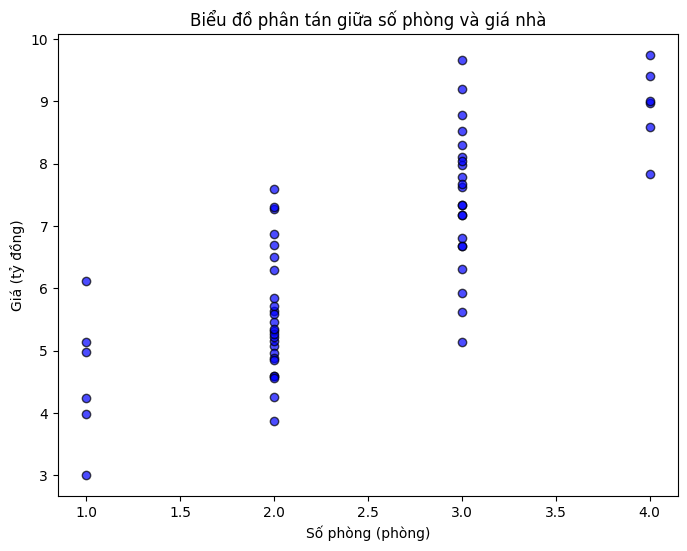

Nhận xét: Giá nhà có xu hướng đồng biến (tăng) theo số lượng phòng; căn hộ càng có nhiều phòng thì giá bán trung bình càng cao.


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")

# 2. Vẽ biểu đồ phân tán giữa số phòng và giá nhà
plt.figure(figsize=(8, 6))
plt.scatter(df["so_phong"], df["gia"], color="blue", alpha=0.7, edgecolors="k")

# 3. Đặt nhãn cho trục hoành, trục tung và tiêu đề cho biểu đồ
plt.xlabel("Số phòng (phòng)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Biểu đồ phân tán giữa số phòng và giá nhà")

# 4. Lưu biểu đồ thành tệp ảnh bai2.png trước khi hiển thị (plt.show)
plt.savefig("bai2.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. In câu nhận xét xu hướng ra màn hình console
print(
    "Nhận xét: Giá nhà có xu hướng đồng biến (tăng) theo số lượng phòng; căn hộ càng có nhiều phòng thì giá bán trung bình càng cao."
)

# Bài tập 3: Đổi biến đầu vào sang tuổi nhà

Hệ số góc w = -0.037858
Hệ số chặn b = 6.983593


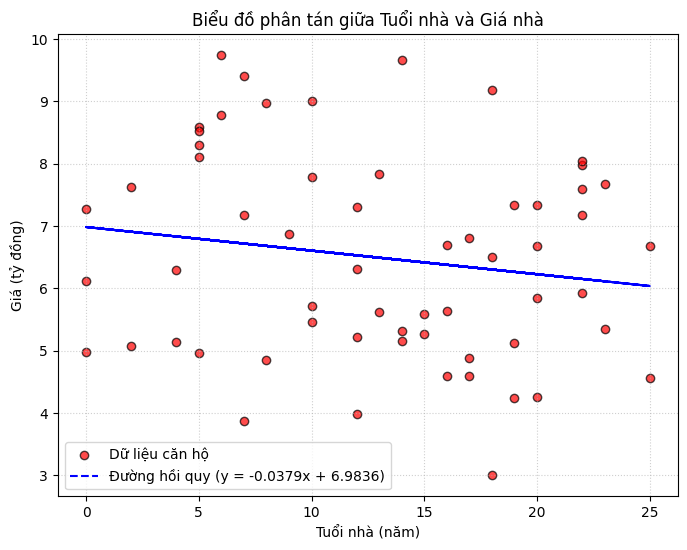


--- NHẬN XÉT VÀ GIẢI THÍCH ---
1. Nhận xét dấu: Hệ số w mang dấu âm (w = -0.037858).
2. Giải thích: Dấu âm thể hiện mối quan hệ nghịch biến. Khi tuổi nhà tăng thêm 1 năm,
   giá nhà có xu hướng giảm đi trung bình khoảng 0.037858 tỷ đồng (~37.86 triệu đồng)
   do sự hao mòn theo thời gian về chất lượng công trình và hạ tầng nội thất.


In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")

# 2. Trích xuất biến đầu vào x (tuoi_nha) và biến mục tiêu y (gia)
x_all = df["tuoi_nha"].to_numpy()
y_all = df["gia"].to_numpy()

# 3. Tính giá trị trung bình
x_tb = x_all.mean()
y_tb = y_all.mean()

# 4. Áp dụng công thức bình phương tối thiểu (OLS)
tu_so = ((x_all - x_tb) * (y_all - y_tb)).sum()
mau_so = ((x_all - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

# 5. In kết quả với 6 chữ số sau dấu phẩy
print(f"Hệ số góc w = {w:.6f}")
print(f"Hệ số chặn b = {b:.6f}")

# 6. Vẽ biểu đồ phân tán và đường hồi quy
plt.figure(figsize=(8, 6))
plt.scatter(
    df["tuoi_nha"],
    df["gia"],
    color="red",
    alpha=0.7,
    edgecolors="k",
    label="Dữ liệu căn hộ",
)
plt.plot(
    x_all,
    w * x_all + b,
    color="blue",
    linestyle="--",
    label=f"Đường hồi quy (y = {w:.4f}x + {b:.4f})",
)
plt.xlabel("Tuổi nhà (năm)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Biểu đồ phân tán giữa Tuổi nhà và Giá nhà")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

# Lưu biểu đồ thành tệp ảnh
plt.savefig("bai3_tuoi_nha.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. In câu giải thích và nhận xét
print("\n--- NHẬN XÉT VÀ GIẢI THÍCH ---")
print("1. Nhận xét dấu: Hệ số w mang dấu âm (w = -0.037858).")
print(
    "2. Giải thích: Dấu âm thể hiện mối quan hệ nghịch biến. Khi tuổi nhà tăng thêm 1 năm,"
)
print(
    "   giá nhà có xu hướng giảm đi trung bình khoảng 0.037858 tỷ đồng (~37.86 triệu đồng)"
)
print(
    "   do sự hao mòn theo thời gian về chất lượng công trình và hạ tầng nội thất."
)

# Bài tập 4: Thêm số phòng vào mô hình

In [21]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# 1. Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")

# 2. Chọn 2 đặc trưng đầu vào (dien_tich, so_phong) và biến mục tiêu (gia)
X = df[["dien_tich", "so_phong"]]
y = df["gia"]

# 3. Chia tập dữ liệu (80% Train - 48 căn, 20% Test - 12 căn)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Khởi tạo và huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# 5. Dự đoán trên tập kiểm tra và tính chỉ số R²
y_pred = mo_hinh.predict(X_test)
r2_multi = r2_score(y_test, y_pred)

# 6. In ra kết quả
print(f"Hệ số R² trên tập kiểm tra (2 biến: dien_tich + so_phong): {r2_multi:.4f}")

# 7. In phần so sánh và đánh giá
print("\n--- SO SÁNH VÀ ĐÁNH GIÁ ---")
print(f"- R² mô hình 1 biến (dien_tich)          : 0.9622")
print(f"- R² mô hình 2 biến (dien_tich + so_phong): {r2_multi:.4f}")
print(
    f"- Mức chênh lệch                             : +{r2_multi - 0.9622:.4f} (+{(r2_multi - 0.9622)*100:.2f}%)"
)
print(
    "\nĐánh giá: Việc thêm cột so_phong LÀ ĐÁNG. Mặc dù diện tích đã giải thích được phần lớn"
)
print(
    "biến động giá (96.22%), việc bổ sung số phòng giúp mô hình nắm bắt thêm cấu trúc không gian"
)
print(
    "nội thất, nâng khả năng giải thích lên 96.98% mà không làm tăng độ phức tạp tính toán đáng kể."
)

Hệ số R² trên tập kiểm tra (2 biến: dien_tich + so_phong): 0.9698

--- SO SÁNH VÀ ĐÁNH GIÁ ---
- R² mô hình 1 biến (dien_tich)          : 0.9622
- R² mô hình 2 biến (dien_tich + so_phong): 0.9698
- Mức chênh lệch                             : +0.0076 (+0.76%)

Đánh giá: Việc thêm cột so_phong LÀ ĐÁNG. Mặc dù diện tích đã giải thích được phần lớn
biến động giá (96.22%), việc bổ sung số phòng giúp mô hình nắm bắt thêm cấu trúc không gian
nội thất, nâng khả năng giải thích lên 96.98% mà không làm tăng độ phức tạp tính toán đáng kể.


# Bài tập 5: Thử hai tốc độ học khác

In [22]:
import numpy as np
import pandas as pd

# 1. Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")
X = df["dien_tich"].values
y = df["gia"].values

# 2. Chuẩn hóa Z-score để Gradient Descent hoạt động ổn định
X_norm = (X - X.mean()) / X.std()


# 3. Định nghĩa hàm chạy Gradient Descent
def run_gradient_descent(toc_do_hoc, so_vong=200):
    w = 0.0
    b = 0.0
    N = len(y)

    for vong in range(1, so_vong + 1):
        y_pred = w * X_norm + b
        error = y_pred - y

        # Tính đạo hàm (Gradient)
        dw = (2 / N) * np.sum(error * X_norm)
        db = (2 / N) * np.sum(error)

        # Cập nhật trọng số
        w -= toc_do_hoc * dw
        b -= toc_do_hoc * db

    # Tính MSE ở vòng lặp cuối cùng (vòng 200)
    mse = np.mean((y_pred - y) ** 2)
    return mse


# 4. Chạy thực nghiệm với 2 tốc độ học theo yêu cầu
mse_0001 = run_gradient_descent(0.001, 200)
mse_102 = run_gradient_descent(1.02, 200)

print(f"MSE ở vòng 200 với tốc độ học 0.001 : {mse_0001:.4f}")
print(f"MSE ở vòng 200 với tốc độ học 1.02  : {mse_102:.4f}")

# 5. Thực nghiệm bổ sung: Thử nghiệm với các mức tốc độ học khác
print("\n--- THỰC NGHIỆM BỔ SUNG (DÒ RANH GIỚI HỘI TỤ) ---")
for lr in [0.1, 0.5, 0.9, 0.99, 1.0, 1.001]:
    mse = run_gradient_descent(lr, 200)
    print(f"Tốc độ học {lr:<5} | MSE ở vòng 200: {mse:.4f}")

MSE ở vòng 200 với tốc độ học 0.001 : 20.2979
MSE ở vòng 200 với tốc độ học 1.02  : 268483526.2887

--- THỰC NGHIỆM BỔ SUNG (DÒ RANH GIỚI HỘI TỤ) ---
Tốc độ học 0.1   | MSE ở vòng 200: 0.1790
Tốc độ học 0.5   | MSE ở vòng 200: 0.1790
Tốc độ học 0.9   | MSE ở vòng 200: 0.1790
Tốc độ học 0.99  | MSE ở vòng 200: 0.1934
Tốc độ học 1.0   | MSE ở vòng 200: 44.8113
Tốc độ học 1.001 | MSE ở vòng 200: 99.0347


# Bài tập 6: Viết hàm dự đoán có cảnh báo

In [23]:
def du_doan_gia(dien_tich):
    # Sử dụng hai hệ số w và b đã huấn luyện từ mục 5
    w = 0.078367
    b = 0.401752

    # Cảnh báo nếu diện tích nằm ngoài khoảng dữ liệu thu thập [35.5, 117.5] m²
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(
            f"[CẢNH BÁO] Diện tích {dien_tich}m² nằm ngoài khoảng dữ liệu quan sát (35.5 - 117.5 m²). Kết quả dự đoán chỉ là suy đoán kéo dài (extrapolation)!"
        )

    # Tính toán giá theo phương trình hồi quy tuyến tính: y = w * x + b
    gia_du_doan = w * dien_tich + b
    return gia_du_doan


# Gọi thử nghiệm với 3 mốc diện tích: 60 m², 80 m² và 200 m²
cac_moc = [60, 80, 200]

for dt in cac_moc:
    gia = du_doan_gia(dt)
    print(f"-> Giá dự đoán cho căn hộ {dt}m² là: {gia:.3f} tỷ đồng\n")

-> Giá dự đoán cho căn hộ 60m² là: 5.104 tỷ đồng

-> Giá dự đoán cho căn hộ 80m² là: 6.671 tỷ đồng

[CẢNH BÁO] Diện tích 200m² nằm ngoài khoảng dữ liệu quan sát (35.5 - 117.5 m²). Kết quả dự đoán chỉ là suy đoán kéo dài (extrapolation)!
-> Giá dự đoán cho căn hộ 200m² là: 16.075 tỷ đồng

